In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Dataset Loaded Successfully")
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Dataset Loaded Successfully
Features Shape: (20640, 8)
Target Shape: (20640,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 16512
Testing Samples: 4128


In [4]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [5]:
y_pred = model.predict(X_test)

In [6]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.5332001304956994
Mean Squared Error (MSE): 0.5558915986952423
Root Mean Squared Error (RMSE): 0.745581383012775
R2 Score: 0.5757877060324523


In [7]:
train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

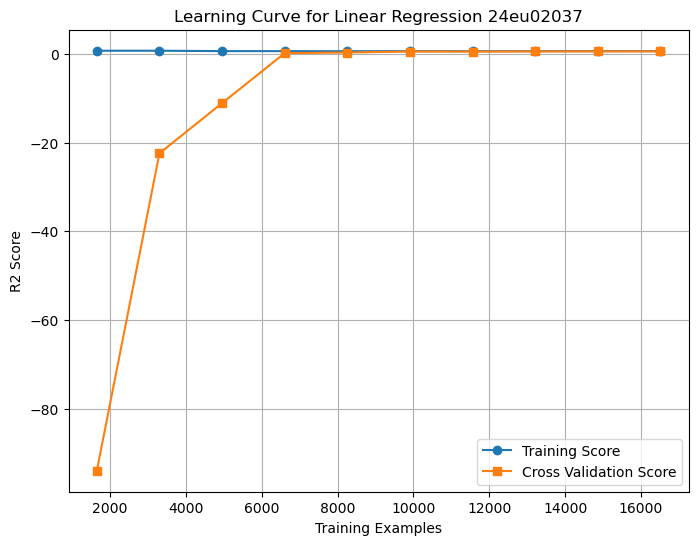

In [12]:
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean,
         marker='o',
         label='Training Score')

plt.plot(train_sizes, test_mean,
         marker='s',
         label='Cross Validation Score')

plt.xlabel("Training Examples")
plt.ylabel("R2 Score")
plt.title("Learning Curve for Linear Regression 24eu02037")
plt.legend()

plt.grid(True)

plt.show()

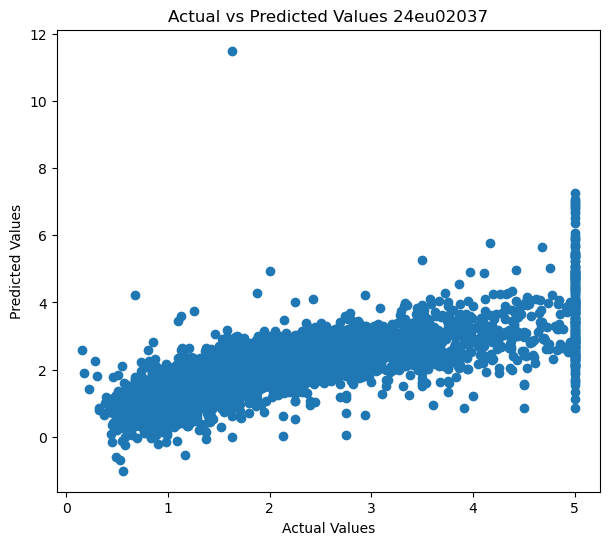

In [11]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values 24eu02037")

plt.show()

In [10]:
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

results

,Metric,Value
0,MAE,0.533200
1,MSE,0.555892
2,RMSE,0.745581
3,R2 Score,0.575788
